In [1]:
import sys
import os
import pandas as pd
import numpy as np
from pycox.models.cox import CoxPH
from pycox.evaluation import EvalSurv
import matplotlib.pyplot as plt
import torchtuples as tt
import shap
sys.path.append(os.path.abspath("../../"))
from src.dataset.generate_dataset import TorchPreprocessing
from src.dataset.DataSet import SurvivalDataSet
from src.utils.Preprocessing import Preprocessor
from src.utils.ConvertTextToCsv import TextToCsv
from src.dataset.split_data import split_data_Train_Val_Test, create_dataloaders_train_val_test
import scipy.integrate
from sklearn.preprocessing import StandardScaler
from src.utils.cox_models import *
scipy.integrate.simps = scipy.integrate.simpson
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.compare import compare_survival
from sksurv.util import Surv
from itertools import product
import torch

import random
import numpy as np
import torch


%load_ext autoreload
%autoreload 2
%matplotlib inline

/Users/administrador/Library/Python/3.11/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed()

In [3]:
pp = Preprocessor()

In [4]:
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_data = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_data)
df_clinical_data["Tumor-Cancer"] = list_df
df_clinical_data["Tumor-Cancer"].unique()

df_mRNA_raw_data = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")


Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 299 - Total(%) 0.37
Shape of the CSV: (20440, 819)


In [5]:
df_merged = TorchPreprocessing(df_mRNA_raw_data,df_clinical_data, 23360).get_comparation_df()
 
comparation_df = df_merged.loc[
    df_merged["Tumor-Cancer"].isin(["Luminal A", "Luminal B", "TNBC", "HER2-enriched"]),
]

comparation_df["Tumor-Cancer"].unique()

print(f"Samples: {comparation_df.shape[0]}, Genes: {comparation_df.shape[1]}")

Genes before Treshold: 20434
count    20434.000000
mean        73.977831
std        155.539160
min          0.000000
25%          0.000000
50%          0.000000
75%         21.000000
max        519.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 18533
Samples: 519, Genes: 18534


In [6]:
zero_reduced_df =  comparation_df.drop(["Sample ID"], axis=1)
results_df, desing, expr = pp.initialize_limma(zero_reduced_df, column="Tumor-Cancer", column_event="Overall Survival (Months)", column_status="Overall Survival Status")

In [7]:
results_df

,HER2-enriched,Luminal A,Luminal B,AveExpr,F,pvalue,adj_pvalue
CLPTM1L,11.102512,11.135727,11.432034,11.178603,3411.584991,0.000000e+00,0.000000e+00
CENPI,5.470060,5.888030,6.715312,5.789382,1450.712650,0.000000e+00,0.000000e+00
MYO7A,6.271601,6.449378,6.908579,6.404052,1924.652991,0.000000e+00,0.000000e+00
TICAM1,9.053592,8.909586,9.122539,9.029430,3672.081507,0.000000e+00,0.000000e+00
ATRN,11.000081,10.966267,10.703819,10.940783,3599.868581,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...
SLC28A2,0.277010,0.242954,0.086340,0.243943,14.846553,1.159021e-09,1.159271e-09
SSX6,0.132164,0.226988,0.328592,0.195638,14.669272,1.503423e-09,1.503666e-09
TMEM229A,0.207897,0.218256,0.103054,0.198622,14.233538,2.848866e-09,2.849174e-09
GADL1,0.142536,0.159804,0.223690,0.175297,13.301483,1.116376e-08,1.116436e-08


In [8]:
N_GENES = 1000
top_genes_limma = results_df.sort_values("pvalue").index[:N_GENES].tolist()

In [9]:
torch_preprocessing = TorchPreprocessing(df_mRNA_raw_data, df_clinical_data, 23360)
torch_preprocessing.genes_expression = top_genes_limma
genes_expression = top_genes_limma
X_scaled, durations, events, scaler = torch_preprocessing.get_data_set(60)



Genes before Treshold: 1003
count    1003.000000
mean        0.929212
std         3.489359
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        42.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 1003


In [10]:
X_scaled.shape

(519, 1000)

In [11]:
surival_data_set  = SurvivalDataSet(X_scaled, durations, events)

In [12]:
set_seed()
(train_X, train_durations, train_events), \
(val_X, val_durations, val_events), \
(test_X, test_durations, test_events) = split_data_Train_Val_Test(surival_data_set)
print(f"Train: {train_X.shape[0]}, Val: {val_X.shape[0]}, Test: {test_X.shape[0]}")

Train: 415, Val: 52, Test: 52


In [13]:
train_X.shape

torch.Size([415, 1000])

Grid Search for the best Model

In [14]:
from itertools import product

in_features = train_X.shape[1]
output_bias = False
param_grid = {
    "num_nodes": [
        [16], [32], [64], [128],
        [16, 16], [32, 16], [32, 32],
    ],
    "dropout": [0.2, 0.4],
    "batch_norm": [True, False],
    "lr": [1e-3, 5e-4, 1e-4],
    "weight_decay": [0, 1e-4, 1e-3],
    "batch_size": [128, 256],
}
grid = list(product(
    param_grid["num_nodes"],
    param_grid["dropout"],
    param_grid["batch_norm"],
    param_grid["lr"],
    param_grid["weight_decay"],
    param_grid["batch_size"],
))

In [15]:
from pycox.evaluation import EvalSurv

best_score = -1
best_params = None
grid_results = []

set_seed()
val_X = np.array(val_X)
val_durations = np.array(val_durations)
val_events = np.array(val_events).astype(bool)

for num_nodes, dp, bn, lr, wd, batch_size in grid:
    try:
        net = tt.torchtuples.practical.MLPVanilla(
            in_features=in_features,
            num_nodes=num_nodes,
            out_features=1,
            dropout=dp,
            output_bias=False,
            batch_norm=bn,
        )
        model_gs = CoxPH(net, tt.torchtuples.optim.Adam(lr=lr, weight_decay=wd))
        
        callbacks = [tt.torchtuples.callbacks.EarlyStopping(patience=20)]
        model_gs.fit(
            input=train_X,
            target=(train_durations, train_events),
            batch_size=batch_size,
            epochs=100,
            callbacks=callbacks,
            verbose=False,
            val_data=(val_X, (val_durations, val_events)),
            val_batch_size=batch_size
        )
        
        
        model_gs.compute_baseline_hazards()
        surv_val = model_gs.predict_surv_df(val_X)
        ev = EvalSurv(surv_val, val_durations, val_events, censor_surv='km')
        c_index = ev.concordance_td()

        grid_results.append({
            'num_nodes': num_nodes, 'dropout': dp, 'batch_norm': bn,
            'lr': lr, 'weight_decay': wd, 'batch_size': batch_size,
            'c_index': c_index
        })

        if c_index > best_score:
            best_score = c_index
            best_params = {
                'num_nodes': num_nodes, 'dropout': dp, 'batch_norm': bn,
                'lr': lr, 'weight_decay': wd, 'batch_size': batch_size
            }
    except Exception as e:
        continue

print(f"Mejor C-index en validación: {best_score:.4f}")
print(f"Mejores parámetros: {best_params}")

Mejor C-index en validación: 0.9386
Mejores parámetros: {'num_nodes': [128], 'dropout': 0.4, 'batch_norm': False, 'lr': 0.0005, 'weight_decay': 0, 'batch_size': 256}


Training the Model

In [16]:

out_features = 1
num_nodes    = best_params['num_nodes']
dropout      = best_params['dropout']
batch_norm   = best_params['batch_norm']
lr           = best_params['lr']
weight_decay = best_params['weight_decay']
batch_size   = best_params['batch_size']


net = tt.torchtuples.practical.MLPVanilla(
    in_features=in_features, 
    num_nodes=num_nodes, 
    out_features=out_features, 
    batch_norm=batch_norm,
    dropout=dropout,
    output_bias=output_bias
)
model = CoxPH(net, tt.torchtuples.optim.Adam(weight_decay=weight_decay))


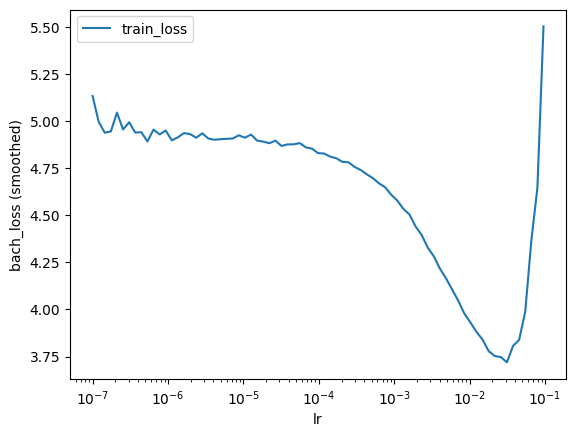

In [17]:
batch_size = batch_size
lrfinder = model.lr_finder(input=train_X,
                           target=(train_durations, train_events),
                           batch_size=batch_size,
                           tolerance=20)

_ = lrfinder.plot()

In [18]:
train_durations.shape

torch.Size([415])

In [19]:
model.optimizer.set_lr(lr)


In [20]:
epochs = 500
callbacks = [tt.torchtuples.callbacks.EarlyStopping(patience=25)]
verbose = True

In [21]:
%%time

set_seed()
torch.manual_seed(SEED)
np.random.seed(SEED)
log = model.fit(input=train_X, target=(train_durations, train_events), epochs=epochs, callbacks=callbacks, verbose=verbose, 
                val_data=(val_X,( val_durations, val_events)), val_batch_size=batch_size)

0:	[0s / 0s],		train_loss: 4.9707,	val_loss: 2.8638
1:	[0s / 0s],		train_loss: 4.3279,	val_loss: 2.7655
2:	[0s / 0s],		train_loss: 3.9518,	val_loss: 2.7318
3:	[0s / 0s],		train_loss: 3.7170,	val_loss: 2.7382
4:	[0s / 0s],		train_loss: 3.4662,	val_loss: 2.7376
5:	[0s / 0s],		train_loss: 3.5169,	val_loss: 2.7627
6:	[0s / 0s],		train_loss: 3.0926,	val_loss: 2.7757
7:	[0s / 0s],		train_loss: 3.2372,	val_loss: 2.7987
8:	[0s / 0s],		train_loss: 2.8163,	val_loss: 2.8448
9:	[0s / 0s],		train_loss: 2.8137,	val_loss: 2.9149
10:	[0s / 0s],		train_loss: 2.6809,	val_loss: 3.0352
11:	[0s / 0s],		train_loss: 2.4894,	val_loss: 3.1511
12:	[0s / 0s],		train_loss: 2.4100,	val_loss: 3.2338
13:	[0s / 0s],		train_loss: 2.3275,	val_loss: 3.2774
14:	[0s / 0s],		train_loss: 2.1421,	val_loss: 3.2536
15:	[0s / 0s],		train_loss: 2.1065,	val_loss: 3.2003
16:	[0s / 0s],		train_loss: 2.1133,	val_loss: 3.1633
17:	[0s / 0s],		train_loss: 2.2159,	val_loss: 3.0646
18:	[0s / 0s],		train_loss: 2.0802,	val_loss: 2.9743
19:

(52, 1000)

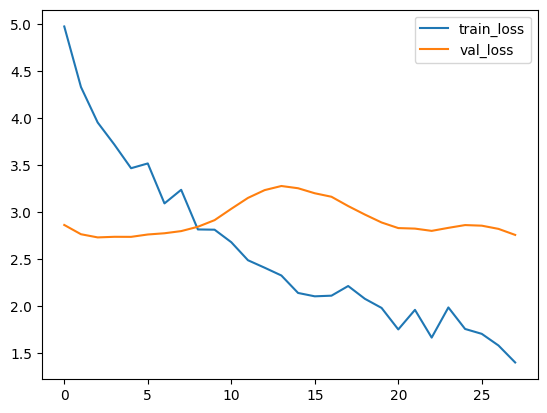

In [22]:
_ = log.plot()
val_X.shape

KapplanMeir Train

In [23]:
risk_nn_train = model.net(train_X).flatten()

list_risk_train = []
for i in risk_nn_train:
    list_risk_train.append(i.item())


For this group the risk High

For the time 0 the risk group is 204
For the time 12 the risk group is 171
For the time 24 the risk group is 100
For the time 36 the risk group is 60
For the time 48 the risk group is 42
For the time 60 the risk group is 0

For this group the risk Low

For the time 0 the risk group is 202
For the time 12 the risk group is 185
For the time 24 the risk group is 115
For the time 36 the risk group is 94
For the time 48 the risk group is 71
For the time 60 the risk group is 0


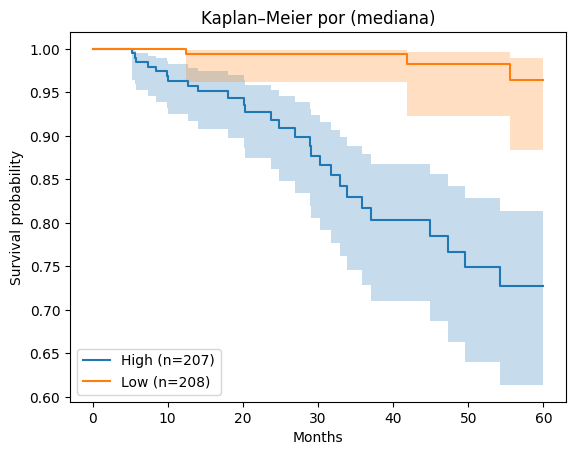

In [24]:
df = pd.DataFrame()

thr = np.median(list_risk_train)
df["group"] = np.where(risk_nn_train > thr, "High", "Low")
df["duration"] = train_durations
df["event"] = train_events

for g in ["High", "Low"]:
        sub = df[df["group"] == g]
        event = sub["event"].to_numpy(dtype=bool)
        time = sub["duration"].to_numpy(dtype=float)
            
        time_points_months = np.array([0, 12, 24, 36, 48, 60])
        at_risk = [(time > tp).sum() for tp in time_points_months]
        print(f"\nFor this group the risk {g}\n")
        x = [(time, risk) for time,risk in zip(time_points_months, at_risk)]
        for i, _ in enumerate(x):
            print(f"For the time {x[i][0]} the risk group is {x[i][1]}")
                
        event_60_month = event.copy()
        event_60_month[time > 120] = False
        time_60_months = np.minimum(time, 120)
        time, prob_survival, conf_int = kaplan_meier_estimator(event_60_month, time_60_months, conf_type="log-log")  # type: ignore # event True=evento, False=censura
        plt.step(time, prob_survival, where="post", label=f"{g} (n={len(sub)})")
        plt.fill_between(time, conf_int[0], conf_int[1], alpha=0.25, step="post")
plt.xlabel("Months")
plt.ylabel("Survival probability")
plt.title(f"Kaplan–Meier por (mediana)")
plt.legend()
plt.show()

In [25]:
time_all = df["duration"].to_numpy(dtype=float)
event_all = df["event"].to_numpy(dtype=bool)
event_60_months = event_all.copy()
event_60_months[time_all > 60] = False
time_60_months = np.minimum(time_all, 60)

y = Surv.from_arrays(event_60_months, time_60_months)
chisq, pvalue = compare_survival(y, df["group"].to_numpy())
print(f"Log-rank: chi2={chisq:.3f}, p={pvalue:.4g}")


Log-rank: chi2=25.665, p=4.062e-07


Log Likehood (The Loss)

In [26]:
model.partial_log_likelihood(*(val_X, (val_durations, val_events))).mean()


-2.7317784

In [27]:
_ = model.compute_baseline_hazards()

In [28]:
surv = model.predict_surv_df(input=test_X)

In [29]:
chf = model.predict_cumulative_hazards(test_X)
chf.shape
#275 → número de puntos de tiempo
#52 -> pacientes 

(275, 52)

Kaplan Meier

In [30]:

risk_nn_test = model.net(test_X).flatten()

list_risk_test = []
for i in risk_nn_test:
    list_risk_test.append(i.item())



For this group the risk High

For the time 0 the risk group is 26
For the time 12 the risk group is 20
For the time 24 the risk group is 12
For the time 36 the risk group is 6
For the time 48 the risk group is 3
For the time 60 the risk group is 0

For this group the risk Low

For the time 0 the risk group is 26
For the time 12 the risk group is 21
For the time 24 the risk group is 13
For the time 36 the risk group is 9
For the time 48 the risk group is 6
For the time 60 the risk group is 0


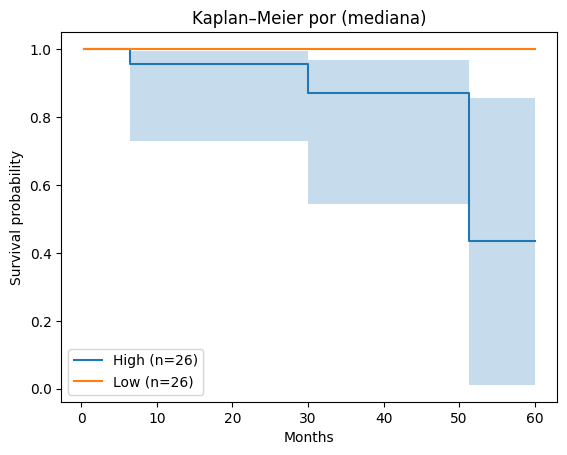

In [31]:
df = pd.DataFrame()

thr = np.median(list_risk_test)
df["group"] = np.where(risk_nn_test > thr, "High", "Low")
df["duration"] = test_durations
df["event"] = test_events

for g in ["High", "Low"]:
        sub = df[df["group"] == g]
        event = sub["event"].to_numpy(dtype=bool)
        time = sub["duration"].to_numpy(dtype=float)
            
        time_points_months = np.array([0, 12, 24, 36, 48, 60])
        at_risk = [(time > tp).sum() for tp in time_points_months]
        print(f"\nFor this group the risk {g}\n")
        x = [(time, risk) for time,risk in zip(time_points_months, at_risk)]
        for i, _ in enumerate(x):
            print(f"For the time {x[i][0]} the risk group is {x[i][1]}")
                
        event_60_month = event.copy()
        event_60_month[time > 120] = False
        time_60_months = np.minimum(time, 120)
        time, prob_survival, conf_int = kaplan_meier_estimator(event_60_month, time_60_months, conf_type="log-log")  # type: ignore # event True=evento, False=censura
        plt.step(time, prob_survival, where="post", label=f"{g} (n={len(sub)})")
        plt.fill_between(time, conf_int[0], conf_int[1], alpha=0.25, step="post")
plt.xlabel("Months")
plt.ylabel("Survival probability")
plt.title(f"Kaplan–Meier por (mediana)")
plt.legend()
plt.show()

Log Rank of the Model

In [32]:

time_all = df["duration"].to_numpy(dtype=float)
event_all = df["event"].to_numpy(dtype=bool)
event_60_months = event_all.copy()
event_60_months[time_all > 60] = False
time_60_months = np.minimum(time_all, 60)

y = Surv.from_arrays(event_60_months, time_60_months)
chisq, pvalue = compare_survival(y, df["group"].to_numpy())
print(f"Log-rank: chi2={chisq:.3f}, p={pvalue:.4g}")


Log-rank: chi2=4.229, p=0.03973


Prediction of survival of the Patients

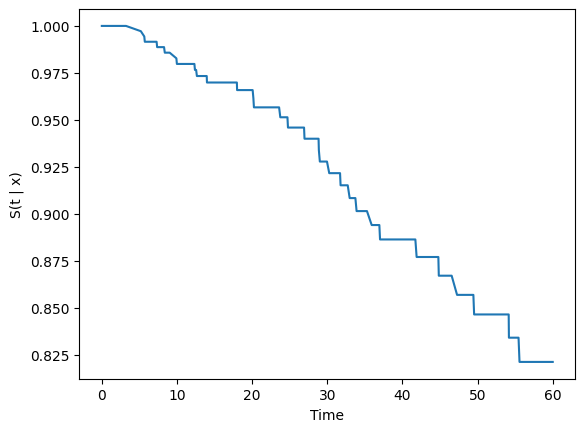

In [33]:
surv.mean(axis=1).plot()
plt.ylabel('S(t | x)')
plt.legend().set_visible(False)
_ = plt.xlabel("Time")

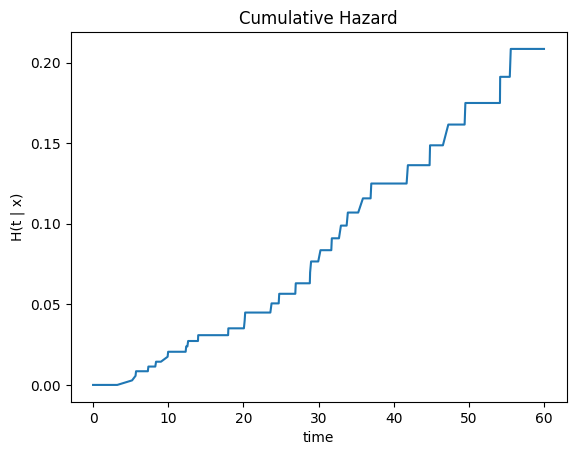

In [34]:
cum_haz = model.predict_cumulative_hazards(test_X)
cuz_model_mean = cum_haz.mean(axis=1)
cuz_model_mean.plot()
plt.xlabel("time")
plt.title("Cumulative Hazard")
plt.ylabel("H(t | x)")
plt.legend().set_visible(False)

In [35]:
test_X = np.array(test_X).astype('float32')
test_durations = np.array(test_durations).flatten()
test_events = np.array(test_events).astype(bool).flatten()

print(f"test_X shape: {test_X.shape}")
print(f"test_durations shape: {test_durations.shape}")
print(f"test_events shape: {test_events.shape}")

test_X shape: (52, 1000)
test_durations shape: (52,)
test_events shape: (52,)


In [36]:
torch.manual_seed(SEED)
np.random.seed(SEED)
ev = EvalSurv(surv=surv,
              durations=test_durations,
              events=test_events,
              censor_surv="km")


Concordance of the Model

In [37]:

print(f"Concordance of the model {ev.concordance_td()}")

Concordance of the model 0.9166666666666666


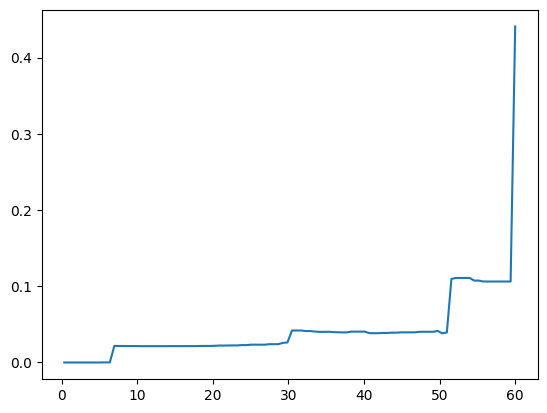

In [38]:
time_grid = np.linspace(test_durations.min(), test_durations.max(), 100)
_ = ev.brier_score(time_grid).plot()

In [39]:
ev.integrated_brier_score(time_grid=time_grid)

0.04025629546325148

In [40]:
ev.integrated_nbll(time_grid)
ci_test_deepsurv = ev.concordance_td()
ibs_deepsurv     = ev.integrated_brier_score(time_grid)

In [41]:
param_grid_cn = {
    "num_nodes":    [[16], [32], [64], [128], [256]],  
    "dropout":      [0.2, 0.4],
    "batch_norm":   [True, False],
    "lr":           [1e-3, 5e-4, 1e-4],
    "weight_decay": [0, 1e-4, 1e-3],
    "batch_size":   [128, 256],
}
grid_cn = list(product(
    param_grid_cn["num_nodes"],
    param_grid_cn["dropout"],
    param_grid_cn["batch_norm"],
    param_grid_cn["lr"],
    param_grid_cn["weight_decay"],
    param_grid_cn["batch_size"],
))

best_score_cn  = -1
best_params_cn = None
grid_results_cn = []
set_seed()
for num_nodes, dp, bn, lr, wd, batch_size in grid_cn:
    try:
        net_cn = tt.torchtuples.practical.MLPVanilla(
            in_features  = in_features,
            num_nodes    = num_nodes,       # lista de 1 elemento
            out_features = 1,
            dropout      = dp,
            output_bias  = False,
            batch_norm   = bn,
        )
        model_cn_gs = CoxPH(net_cn, tt.torchtuples.optim.Adam(lr=lr, weight_decay=wd))

        callbacks = [tt.torchtuples.callbacks.EarlyStopping(patience=5)]
        model_cn_gs.fit(
            input      = train_X,
            target     = (train_durations, train_events),
            batch_size = batch_size,
            epochs     = 100,
            callbacks  = callbacks,
            verbose    = False,
            val_data   = (val_X, (val_durations, val_events)),
            val_batch_size = batch_size,
        )

        model_cn_gs.compute_baseline_hazards()
        surv_val_cn = model_cn_gs.predict_surv_df(val_X)
        ev_cn_gs    = EvalSurv(surv_val_cn, val_durations, val_events, censor_surv='km')
        c_index_cn  = ev_cn_gs.concordance_td()

        grid_results_cn.append({
            'num_nodes': num_nodes, 'dropout': dp, 'batch_norm': bn,
            'lr': lr, 'weight_decay': wd, 'batch_size': batch_size,
            'c_index': c_index_cn
        })

        if c_index_cn > best_score_cn:
            best_score_cn  = c_index_cn
            best_params_cn = {
                'num_nodes': num_nodes, 'dropout': dp, 'batch_norm': bn,
                'lr': lr, 'weight_decay': wd, 'batch_size': batch_size
            }
    except Exception as e:
        continue

print(f"Mejor C-index en validación (Cox-nnet): {best_score_cn:.4f}")
print(f"Mejores parámetros: {best_params_cn}")

Mejor C-index en validación (Cox-nnet): 0.9298
Mejores parámetros: {'num_nodes': [32], 'dropout': 0.4, 'batch_norm': True, 'lr': 0.0005, 'weight_decay': 0.001, 'batch_size': 256}


In [42]:
set_seed()
torch.manual_seed(SEED)
np.random.seed(SEED)
net_cn = tt.torchtuples.practical.MLPVanilla(
    in_features=in_features, num_nodes=best_params_cn['num_nodes'],
    out_features=1, batch_norm=best_params_cn['batch_norm'],
    dropout=best_params_cn['dropout'], output_bias=False,
)
model_cn = CoxPH(net_cn, tt.torchtuples.optim.Adam(
    lr=best_params_cn['lr'], weight_decay=best_params_cn['weight_decay']
))
model_cn.fit(
    input=train_X, target=(train_durations, train_events),
    batch_size=best_params_cn['batch_size'], epochs=200, verbose=True,
    callbacks=[tt.torchtuples.callbacks.EarlyStopping(patience=15)],
    val_data=(val_X, (val_durations, val_events)),
)

model_cn.compute_baseline_hazards()
surv_cn = model_cn.predict_surv_df(test_X)
ev_cn   = EvalSurv(surv_cn, test_durations, test_events, censor_surv='km')

ci_test_coxnnet = ev_cn.concordance_td()


0:	[0s / 0s],		train_loss: 4.9290,	val_loss: 2.8776
1:	[0s / 0s],		train_loss: 4.8137,	val_loss: 2.8368
2:	[0s / 0s],		train_loss: 4.4216,	val_loss: 2.8078
3:	[0s / 0s],		train_loss: 4.3154,	val_loss: 2.7881
4:	[0s / 0s],		train_loss: 4.1729,	val_loss: 2.7807
5:	[0s / 0s],		train_loss: 3.9548,	val_loss: 2.7838
6:	[0s / 0s],		train_loss: 4.0729,	val_loss: 2.7779
7:	[0s / 0s],		train_loss: 3.8619,	val_loss: 2.7637
8:	[0s / 0s],		train_loss: 3.6887,	val_loss: 2.7455
9:	[0s / 0s],		train_loss: 3.7525,	val_loss: 2.7290
10:	[0s / 0s],		train_loss: 3.5670,	val_loss: 2.7183
11:	[0s / 0s],		train_loss: 3.3571,	val_loss: 2.7004
12:	[0s / 0s],		train_loss: 3.2919,	val_loss: 2.6882
13:	[0s / 0s],		train_loss: 3.2642,	val_loss: 2.6805
14:	[0s / 0s],		train_loss: 3.1010,	val_loss: 2.6775
15:	[0s / 0s],		train_loss: 3.0931,	val_loss: 2.6732
16:	[0s / 0s],		train_loss: 2.8733,	val_loss: 2.6759
17:	[0s / 0s],		train_loss: 2.9683,	val_loss: 2.6884
18:	[0s / 0s],		train_loss: 2.7349,	val_loss: 2.7010
19:

In [43]:
print(f"\nC-index test  DeepSurv : {ev.concordance_td():.4f}  capas: {best_params['num_nodes']}")
print(f"C-index test  Cox-nnet : {ci_test_coxnnet:.4f}  capas: {best_params_cn['num_nodes']}")


C-index test  DeepSurv : 0.9167  capas: [128]
C-index test  Cox-nnet : 0.9444  capas: [32]


In [51]:
train_X_np = train_X.cpu().numpy()
train_durations_np = train_durations.cpu().numpy()
train_events_np = train_events.cpu().numpy()


train_X_np.shape, train_durations_np.shape, train_events_np.shape

((415, 1000), (415,), (415,))

In [53]:
from sklearn.utils import resample


set_seed()
N_BOOTSTRAP = 10
gene_shap_records = {gene: [] for gene in genes_expression}

event_idx    = np.where(train_events_np == 1)[0]
no_event_idx = np.where(train_events_np == 0)[0]

for i in range(N_BOOTSTRAP):
    idx_ev = resample(event_idx,    random_state=i, replace=True)
    idx_no = resample(no_event_idx, random_state=i, replace=True)
    idx    = np.concatenate([idx_ev, idx_no])

    X_boot   = train_X_np[idx]
    dur_boot = train_durations_np[idx]
    ev_boot  = train_events_np[idx]

    ev_boot_idx    = np.where(ev_boot == 1)[0]
    no_ev_boot_idx = np.where(ev_boot == 0)[0]
    
    val_ev = resample(ev_boot_idx,    n_samples=max(3, int(0.15*len(ev_boot_idx))),    random_state=i, replace=False)
    val_no = resample(no_ev_boot_idx, n_samples=max(5, int(0.15*len(no_ev_boot_idx))), random_state=i, replace=False)
    val_idx = np.concatenate([val_ev, val_no])
    train_idx = np.setdiff1d(np.arange(len(X_boot)), val_idx)

    X_tr, X_val       = X_boot[train_idx],   X_boot[val_idx]
    dur_tr, dur_val   = dur_boot[train_idx],  dur_boot[val_idx]
    ev_tr,  ev_val    = ev_boot[train_idx],   ev_boot[val_idx]

    net_boot = tt.practical.MLPVanilla(
        in_features=in_features,
        num_nodes=best_params['num_nodes'],
        out_features=1,
        batch_norm=best_params['batch_norm'],
        dropout=best_params['dropout'],
        output_bias=False
    )

    model_boot = CoxPH(
        net_boot,
        tt.optim.Adam(lr=best_params['lr'], weight_decay=best_params['weight_decay'])
    )

    model_boot.fit(
        X_tr, (dur_tr, ev_tr),
        batch_size=best_params['batch_size'],
        epochs=200,
        verbose=False,
        callbacks=[tt.callbacks.EarlyStopping(patience=10)],
        val_data=(X_val, (dur_val, ev_val)),
    )

    def predict_fn(x):
        x_tensor = torch.tensor(x, dtype=torch.float32)
        with torch.no_grad():
            out = model_boot.net(x_tensor)
        return out.cpu().numpy().reshape(-1)

    preds_check = predict_fn(X_boot[:5])
    if np.isnan(preds_check).any():
        print(f"  → Bootstrap {i+1} divergió, saltando")
        continue

    background   = shap.sample(X_boot, 50)
    explainer    = shap.explainers.Permutation(
        predict_fn, background,
        feature_names=genes_expression,
        max_evals=2001
    )
    shap_values  = explainer(test_X_np)
    mean_abs     = np.abs(shap_values.values).mean(axis=0)

    for j, gene in enumerate(genes_expression):
        gene_shap_records[gene].append(mean_abs[j])

    print(f"Bootstrap {i+1}/{N_BOOTSTRAP} OK")

PermutationExplainer explainer: 53it [01:34,  2.01s/it]                        


Bootstrap 1/10 OK


PermutationExplainer explainer: 53it [01:34,  2.01s/it]                        


Bootstrap 2/10 OK


PermutationExplainer explainer: 53it [01:34,  2.00s/it]                        


...

Bootstrap 8/10 OK


PermutationExplainer explainer: 53it [01:39,  2.11s/it]                        


Bootstrap 9/10 OK


PermutationExplainer explainer: 53it [01:40,  2.13s/it]                        

Bootstrap 10/10 OK


In [70]:
gene_shap_records["ABI2"]


[0.04731754555792297,
 0.08280116819167654,
 0.04770270395124009,
 0.0940808756950383,
 0.0607009580795868,
 0.068065753609945,
 0.07558926440701516,
 0.06376406388661754,
 0.07307183827300412,
 0.06377472711735979]

In [77]:
valid_genes = [g for g in genes_expression if len(gene_shap_records[g]) > 0]

mean_shap = np.array([np.mean(gene_shap_records[g]) for g in valid_genes])
std_shap  = np.array([np.std(gene_shap_records[g])  for g in valid_genes])
stability = np.array([np.mean(np.array(gene_shap_records[g]) > 0) for g in valid_genes])

bootstrap_df = pd.DataFrame({
    'gene':      valid_genes,
    'mean_shap': mean_shap,
    'std_shap':  std_shap,
    'stability': stability
}).sort_values('mean_shap', ascending=False)

bootstrap_df.head(20)

,gene,mean_shap,std_shap,stability
946,NME9,0.080078,0.013602,1.0
734,LOC400043,0.077974,0.014411,1.0
921,PKP2,0.077668,0.011041,1.0
524,NXT2,0.076886,0.013685,1.0
255,OSBPL9,0.076878,0.018012,1.0
792,GMPPB,0.076552,0.010094,1.0
836,HSD11B2,0.075955,0.013313,1.0
545,USP13,0.075955,0.011888,1.0
943,PDZD11,0.075928,0.014067,1.0
959,JCHAIN,0.075799,0.014915,1.0


In [78]:
import scipy.stats as stats

correlations = []

for i, gene in enumerate(genes_expression):
    corr, _ = stats.pearsonr(test_X_np[:, i], shap_values.values[:, i])
    correlations.append(corr)

df_corr = pd.DataFrame({
    "gene": genes_expression,
    "correlation": correlations
}).sort_values("correlation", ascending=False)

df_corr.head(20)

,gene,correlation
457,DGAT2,0.840241
789,FRG1,0.752815
118,SPTBN2,0.716642
836,HSD11B2,0.666934
168,COL4A3BP,0.607465
530,MTFR1,0.601487
696,IQSEC2,0.590858
422,NOV,0.588583
578,PRKCDBP,0.584659
779,TNFSF13,0.580382
